In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Aufgabe 1

In [3]:
df = pd.read_csv("rawdata_luftqualitaet.csv")
df

,humidity_inside,temperature_inside,co2_inside,temperature_heater,temperature_wall_inside,state_air_quality
0,58.94,21.955,1653,41.187,14.062,1
1,58.97,21.940,1665,40.937,14.062,1
2,57.89,22.353,1707,40.375,14.250,1
3,58.96,22.504,1981,40.875,14.375,1
4,57.74,22.515,1868,40.812,14.375,1
...,...,...,...,...,...,...
911,37.92,21.714,891,24.312,8.937,1
912,37.89,23.263,1165,52.250,10.062,1
913,39.82,23.043,1348,48.812,10.000,1
914,39.76,23.508,1470,51.375,10.312,1


In [7]:
df.corr()

,humidity_inside,temperature_inside,co2_inside,temperature_heater,temperature_wall_inside,state_air_quality
humidity_inside,1.000000,-0.140898,0.262427,-0.311220,0.526373,0.103207
temperature_inside,-0.140898,1.000000,0.611069,0.681945,0.417373,0.276695
co2_inside,0.262427,0.611069,1.000000,0.253096,0.290896,0.669530
temperature_heater,-0.311220,0.681945,0.253096,1.000000,0.140398,0.091108
temperature_wall_inside,0.526373,0.417373,0.290896,0.140398,1.000000,0.035222
state_air_quality,0.103207,0.276695,0.669530,0.091108,0.035222,1.000000


## Heatmap
Correlation der untershiedlichen parameter

<Axes: >

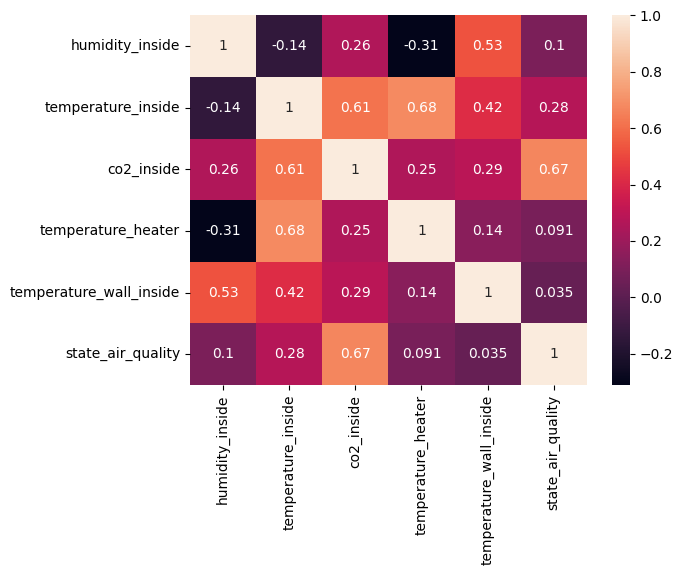

In [27]:
sns.heatmap(df.corr(), annot=True)

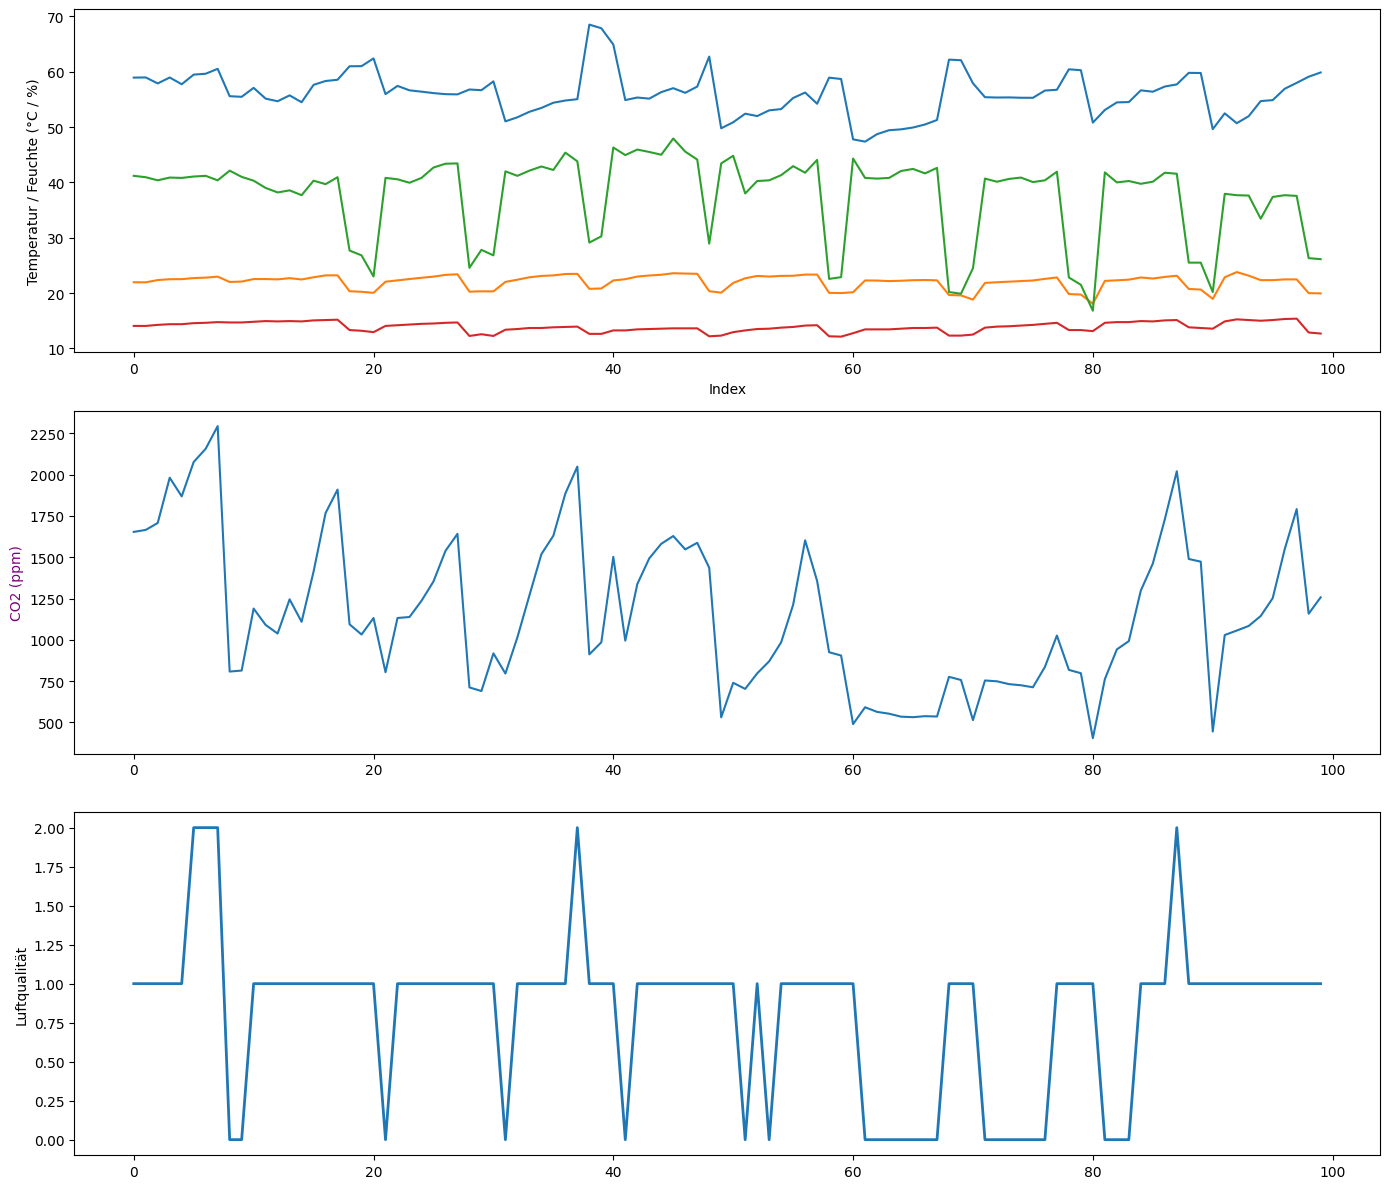

In [50]:
# Liniendiagramm - Zeitreihen mit verschiedenen Achsenskalen

lineData = df[:100]

_, ((plts)) = plt.subplots(3, 1, figsize=(14, 12))

# Hauptachse für °C Werte (Temperatur, Feuchte)
temp_columns = [col for col in lineData.columns if col not in ["state_air_quality", "co2_inside"]]
for i, column in enumerate(temp_columns):
    plts[0].plot(lineData.index, lineData[column], label=column, linewidth=1.5)

plts[0].set_xlabel('Index')
plts[0].set_ylabel('Temperatur / Feuchte (°C / %)', color='black')

# Zweite y-Achse für CO2 (ppm)
plts[1].plot(lineData.index, lineData['co2_inside'], label='co2_inside (ppm)', linewidth=1.5)
plts[1].set_ylabel('CO2 (ppm)', color='purple')

plts[2].plot(lineData.index, lineData['state_air_quality'], label='state_air_quality', linewidth=2)
plts[2].set_ylabel('Luftqualität')

plt.tight_layout()

Niedrige CO2 Werte hängen mit schlechter Luftqualität zusammen

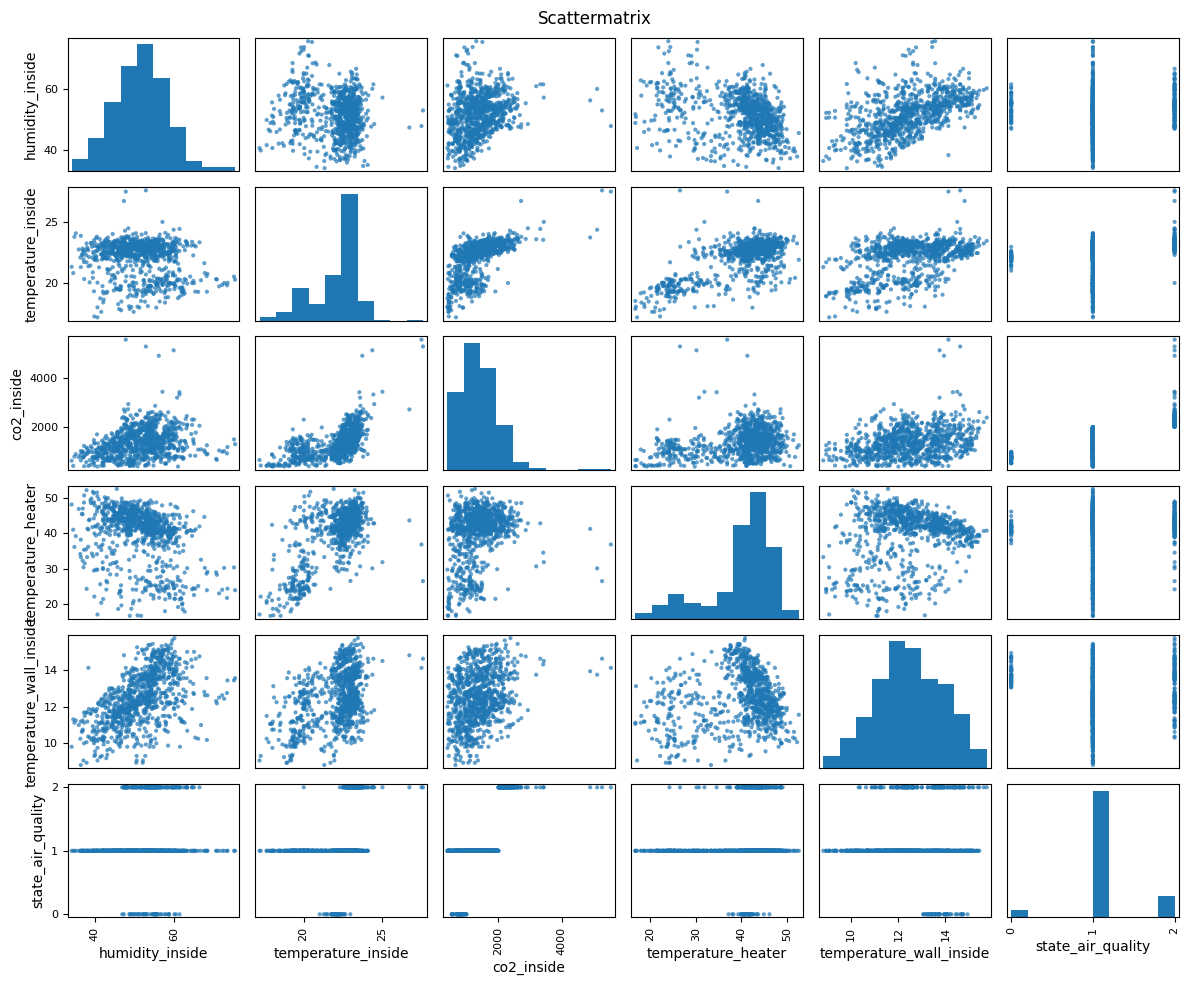

In [29]:
# Scattermatrix - Paarweise Beziehungen zwischen Parametern
from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(12, 10), diagonal='hist', alpha=0.7)

plt.suptitle('Scattermatrix')
plt.tight_layout() # un tights the layout by adding spacing between teh diagrams


Das die Punkte mit schlechter Luftqualität nur bei normalen Temperaturen sind, könnte duch ein fehlen an Daten an den "Unbequemen" Temperaturen liegen.

In [31]:
df.min()

humidity_inside             34.120
temperature_inside          17.194
co2_inside                 395.000
temperature_heater          16.687
temperature_wall_inside      8.812
state_air_quality            0.000
dtype: float64

In [32]:
df.max()

humidity_inside              75.510
temperature_inside           27.613
co2_inside                 5544.000
temperature_heater           52.625
temperature_wall_inside      15.750
state_air_quality             2.000
dtype: float64

In [33]:
df.std()

humidity_inside              6.706102
temperature_inside           1.457741
co2_inside                 588.854522
temperature_heater           7.383326
temperature_wall_inside      1.421408
state_air_quality            0.422532
dtype: float64

68% of values are within the range, described by the standard deviation around the average

In [36]:
df.mean()

humidity_inside              51.598799
temperature_inside           22.103834
co2_inside                 1381.217249
temperature_heater           40.034884
temperature_wall_inside      12.482422
state_air_quality             1.085153
dtype: float64

In [34]:
df.count()

humidity_inside            916
temperature_inside         916
co2_inside                 916
temperature_heater         916
temperature_wall_inside    916
state_air_quality          916
dtype: int64

### Fazit

Stickige räume sind besser?!

# Aufgabe 2